# Phase 2 Notebook 1: Data Transformation

# Overview of Phase 2 — Notebook 1

> **Phase 2 — Notebook 1 of 2** | This notebook is part of a two-phase credit risk model development and validation project. Phase 2 applies and extends the methodology from Phase 1 to a larger dataset of 45,000 observations, incorporating regulatory improvements identified during Phase 1 validation.

This notebook prepares the Phase 2 dataset for modeling. Building on the methodology established in Phase 1, it applies regulatory improvements including exclusion of protected characteristics, variable-by-variable transformation decisions, and stricter no-leakage pipeline design.

The project is divided into two parts:

1. EDA and Data Transformation
2. Modeling and Risk Analysis

The dataset used in this project was obtained from:https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data and contains demographic and financial information for 45,000 loan applicants.

### Approach

This notebook focuses on exploratory data analysis and data preparation. All transformation decisions are evaluated on training data only and applied to both train and test sets to prevent data leakage.

The following steps are performed:

- Initial inspection: no missing values or duplicate rows, this means simpler preprocessing than Phase 1
- Exclusion of person_age and person_gender on regulatory grounds. GDPR Article 22 and EBA guidelines on non-discriminatory credit models
- Exploratory data analysis: univariate and bivariate analysis on full dataset prior to split, documented as acceptable since no transformation parameters are derived
- Train/test split (80/20, stratified) before transformation
- Skewness-based transformation: variable-by-variable decisions with threshold at absolute skewness > 1 for winsorization and > 2 for log transformation
- Reference category encoding to prevent dummy variable trap in logistic regression
- Cramér's V for categorical feature selection — appropriate for large datasets where chi-squared p-values are uninformative

### Business Context

Financial institutions use credit risk modeling to assess the likelihood of borrowers repaying loans. Poor lending decisions increase default risk and financial losses. Phase 2 applies the same credit risk methodology as Phase 1 with regulatory improvements, demonstrating how a model development framework matures across iterations.

### Key Improvements Over Phase 1

- Protected characteristics excluded on regulatory grounds
- Transformation decisions made variable-by-variable based on skewness evidence
- Stricter train/test pipeline, split performed before any transformation
- Reference category dropped from each multi-category variable to prevent perfect multicollinearity in logistic regression

### Important Note

The target variable is loan approval status, not observed default. This is an application scorecard, true PD estimation requires post-approval repayment data which is not available in this dataset. This limitation is consistent with Phase 1 
and applies equally to both projects.

### References

- Muhammad Faizin Zen — Building a Credit Score Model series (Medium, 2025)
- Louis Deconinck — Credit Risk Modelling: Probability of Default (Kaggle, 2023)
- EBA Guidelines on non-discriminatory credit models
- GDPR Article 22 — Automated individual decision-making

### Table of Contents

1. Overview
2. Packages Used
3. Downloading and Initial Inspection
   - 3.1 Inspecting Datatypes
   - 3.2 Checking for Missing Data and Duplicated Rows
4. Exploratory Data Analysis
   - 4.1 Target Variable
   - 4.2 Univariate Analysis
      - 4.2.1 Categorical Data
      - 4.2.2 Numeric Data
   - 4.3 Bivariate Analysis
      - 4.3.1 Categorical Data
      - 4.3.2 Numeric Data
5. Train/Test Split
6. Data Transformation
   - 6.1 Initial Feature Selection
   - 6.2 Skewness Assessment
   - 6.3 Winsorization and Log Transformation
   - 6.4 Comparison Before and After Transformation
   - 6.5 One-Hot Encoding and Label Encoding
   - 6.6 Test Data Transformation
7. Saving Data
8. Conclusion

<h1 style="text-align: center;">Variables in Data explained</h1>

| Column | Description | Datatype |
|------------------------------------|-------------------------------------|-------------|
| **person_age** | Age of the applicant | Float|
| **person_gender** | Gender of the applicant | Categorical |
| **person_education** | Highest education level | Categorical |
| **person_income** | Annual income | Float |
| **person_emp_exp** | Years of employment experience | Integar |
| **person_home_ownership** | Home ownership status | Categorical |
| **loan_amnt** | Loan amount requested | Float |
| **loan_intent** | Purpose of loan | Categorical |
| **loan_int_rate** | Loan interst rate | Float |
| **loan_percent_income** | Loan amount as percentage of annual income | Float |
| **cb_person_cred_hist_length** | Length of cerdit history in years | Float |
| **credit_score** | Credit score of the person | Integer |
| **previous_loan_defaults_in_file** | Indicator of previous loan defaults | Categorical |
| **loan_status** | Loan approval status: 1 = approved; 0 = rejected | Integar |

# 2. Packages Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Downloading and Initial Inspection of Data 

In [2]:
#Downloading Data
df = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\raw_data\loan_data.csv")
print("Size of dataframe:",df.shape)
df.head()

Size of dataframe: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 3.1 Inspecting Datatypes

In [3]:
#Data types present
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## 3.2 Checking for Duplicated Rows and Missing Data

In [4]:
#also check duplication of rows
print("Duplicated rows:", len(df)-len(df.drop_duplicates()), "\n")
print("Missing values:", df.isna().sum().sum())

Duplicated rows: 0 

Missing values: 0


Since there are no duplicated rows or missing values, next step is exploratory data analysis (EDA)

# 4. Exploratory Data Analysis 

EDA was conducted on the full dataset prior to the train/test split. No transformation parameters were derived during EDA — all fitting decisions (winsorization limits, scaler parameters) were applied to training data only in Section 6.

In [5]:
target = df["loan_status"]
eda = df.copy()
numeric_cols = eda.select_dtypes(include="number").columns.tolist()
categorical_cols = eda.select_dtypes(include=["object"]).columns.tolist()

## 4.1 Target Variable

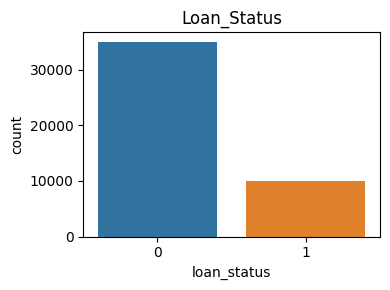

Number of excepted and not excepted loans:
 0    77.777778
1    22.222222
Name: loan_status, dtype: float64


In [6]:
plt.figure(figsize=(4,3))

sns.countplot(data=df, x="loan_status")
plt.title("Loan_Status")

plt.tight_layout()
plt.show()
print("Number of excepted and not excepted loans:\n", 
      ((df["loan_status"].value_counts())/(df["loan_status"].value_counts().sum()))*100)

We can see majority loans do not get approved.

## 4.2 Univariete Analysis

### 4.2.1 Categorical Data

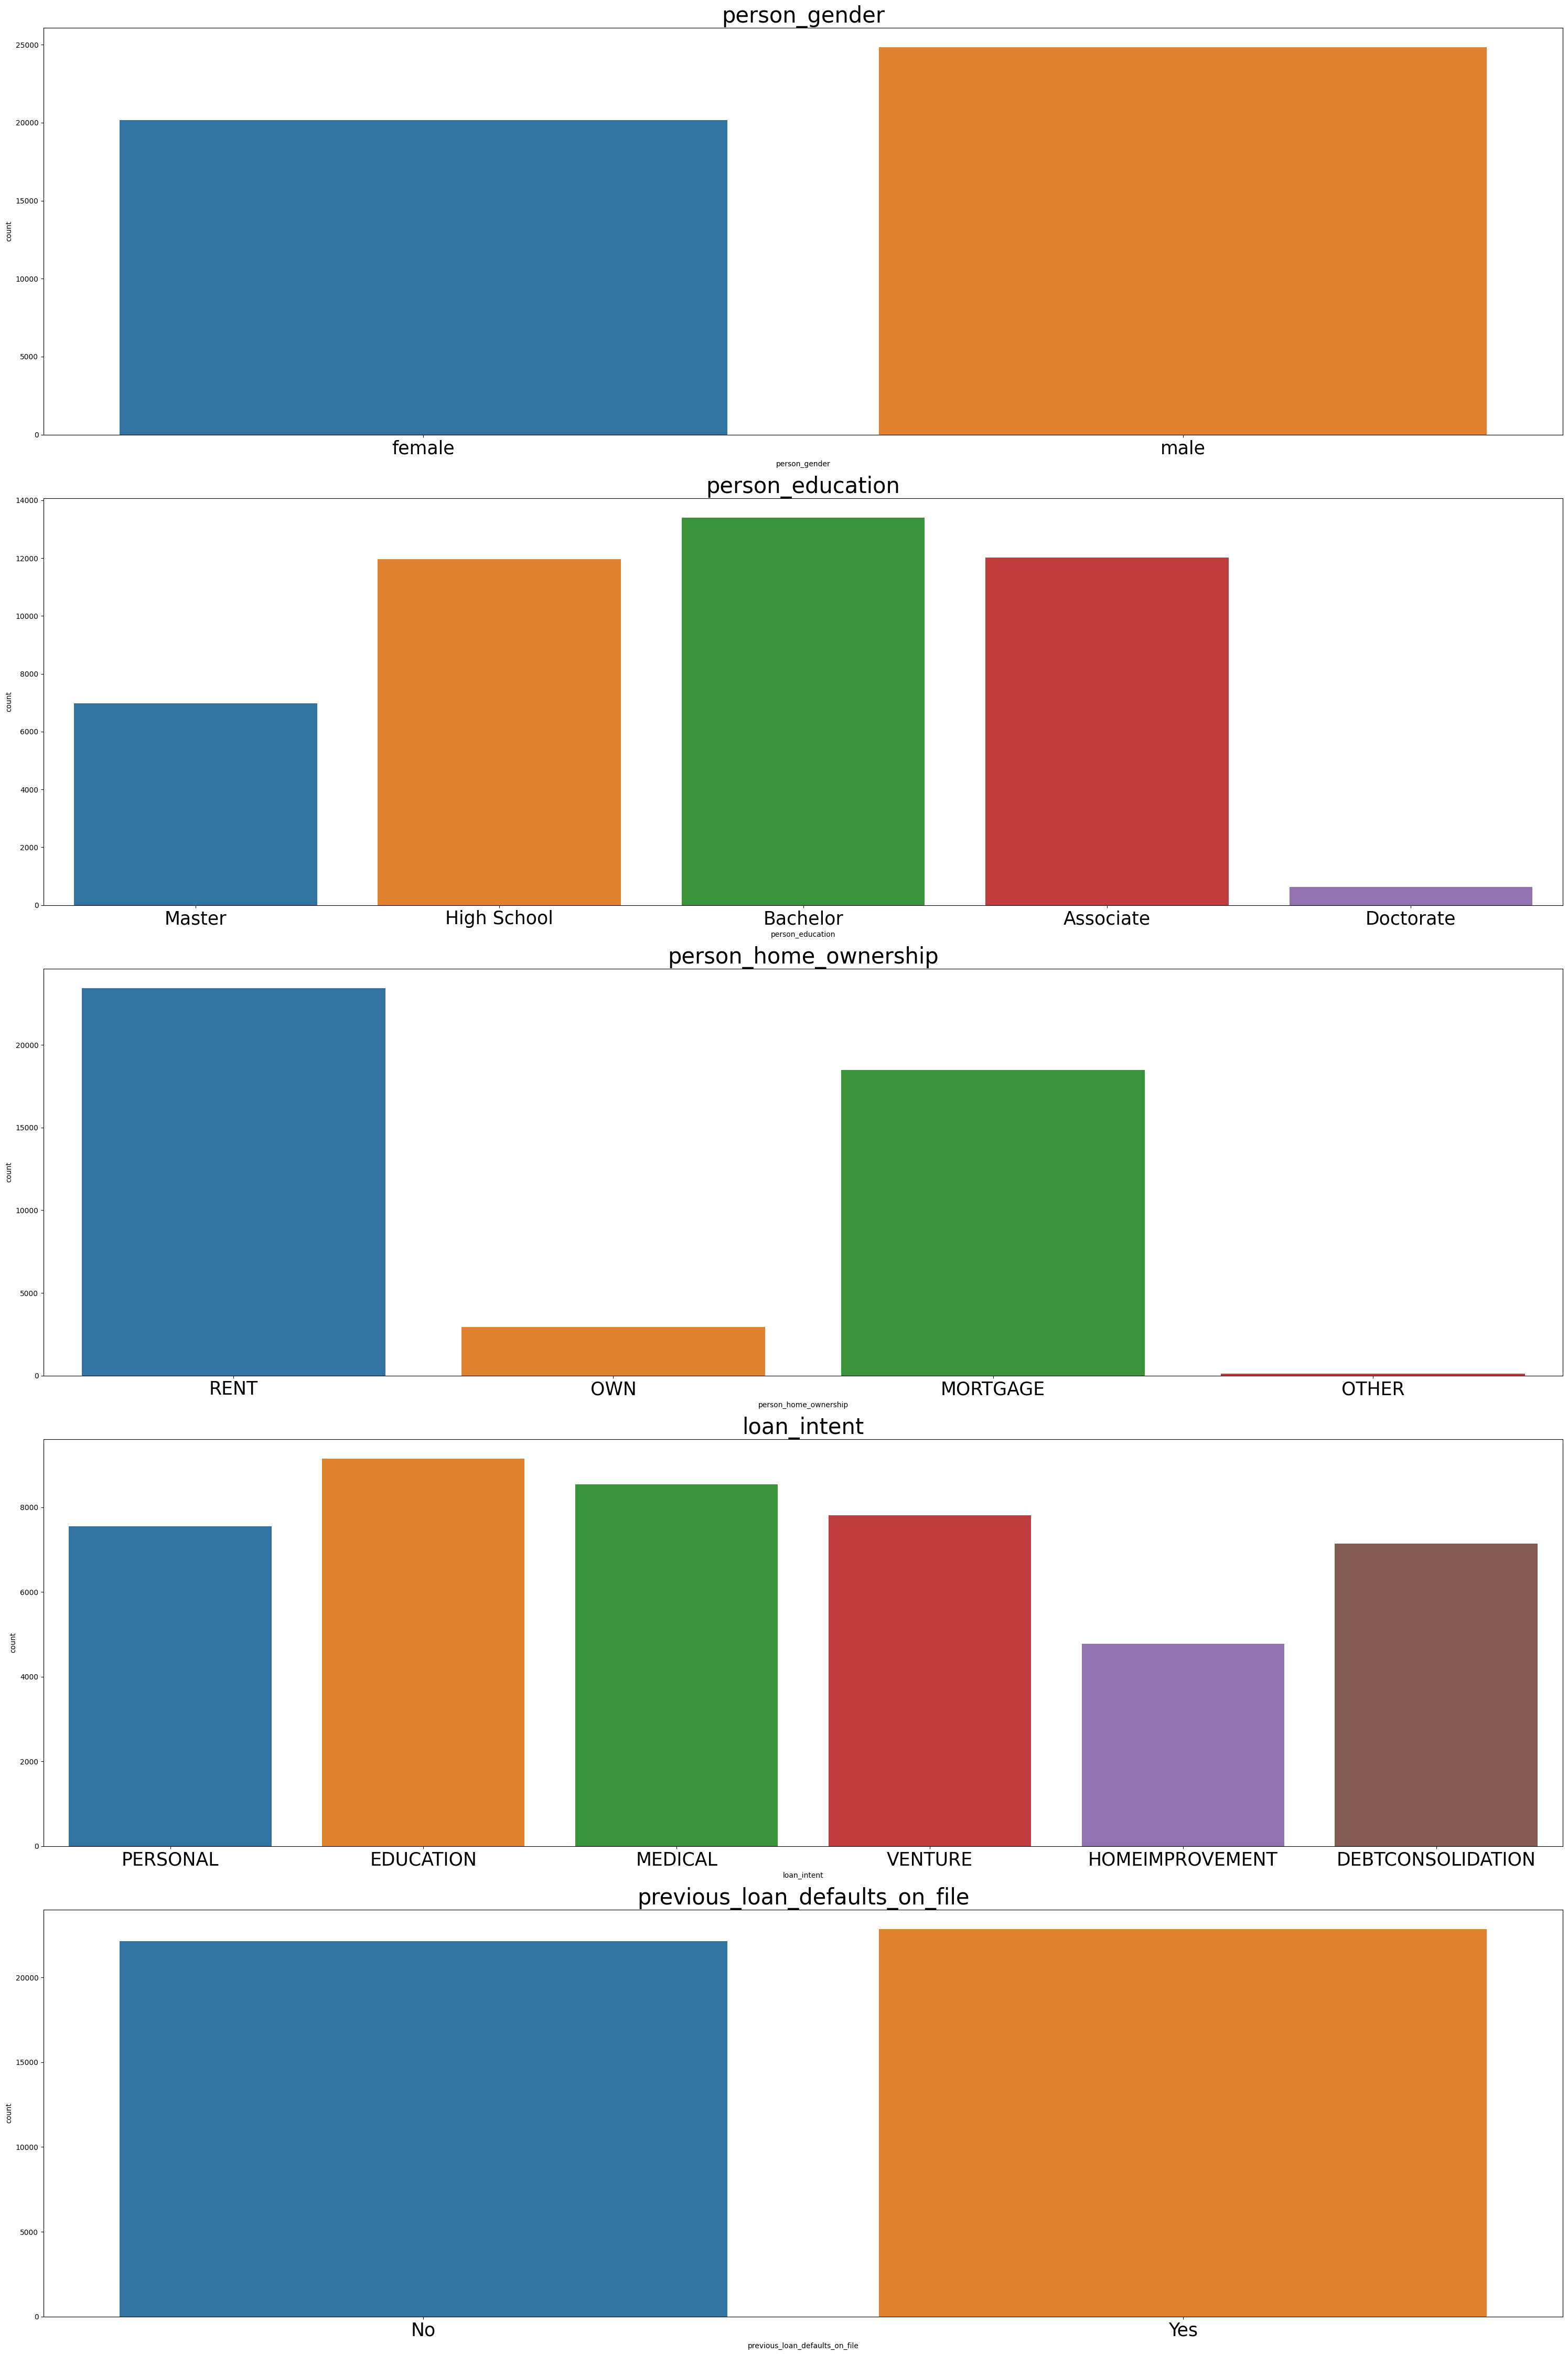

In [7]:
plt.figure(figsize=(30, 45))
plot_idx = 1
for col in categorical_cols:
    if col == "loan_status":
        continue
    plt.subplot(5, 1, plot_idx)
    sns.countplot(data=eda, x=col)
    plt.title(col, fontsize=30)
    plt.xticks(fontsize=25)  
    plot_idx += 1

plt.tight_layout()
plt.show()

### 4.2.2 Numeric Data

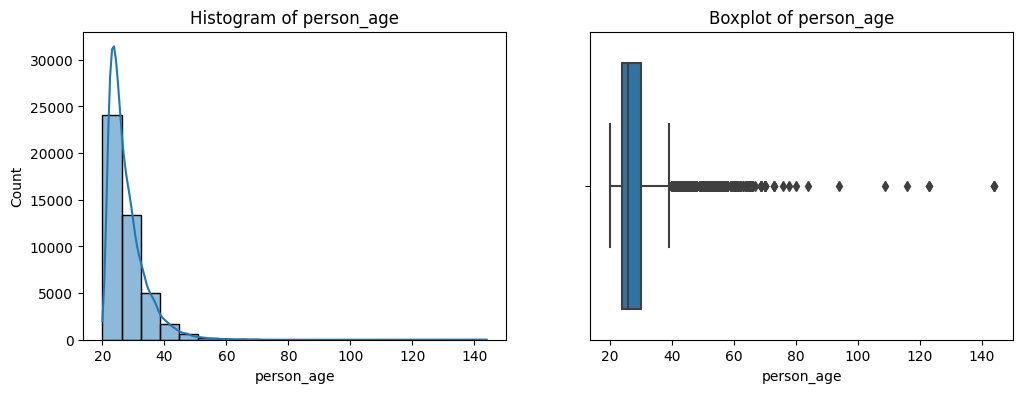

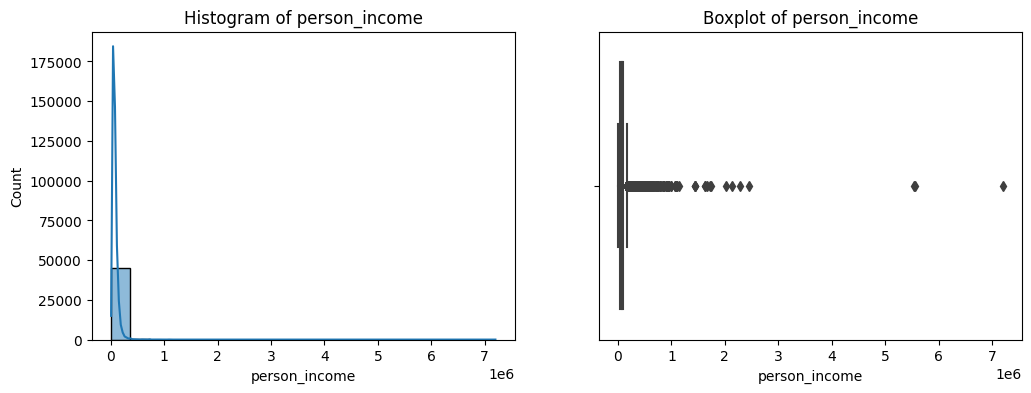

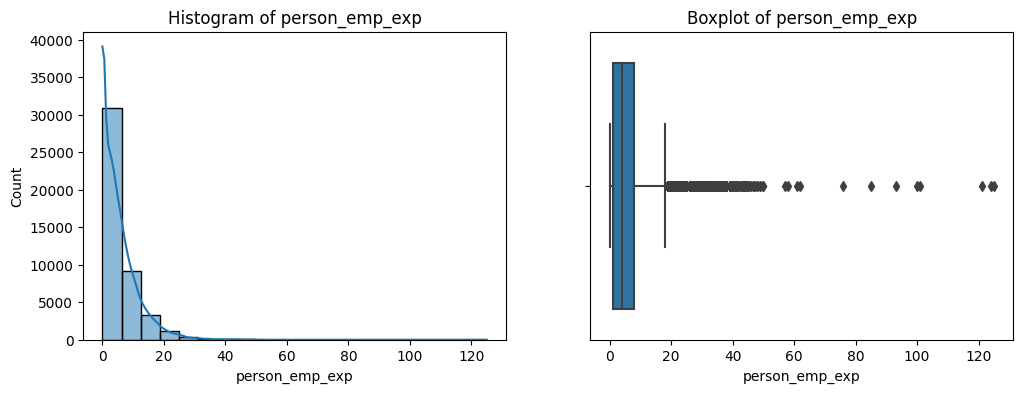

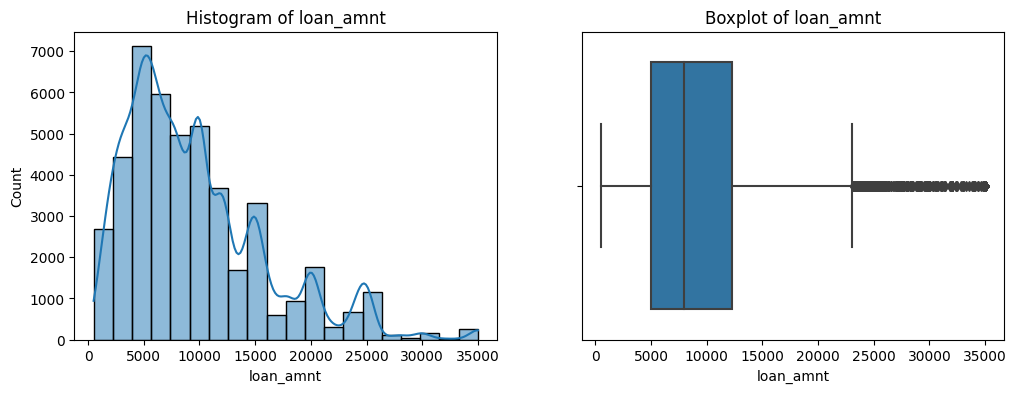

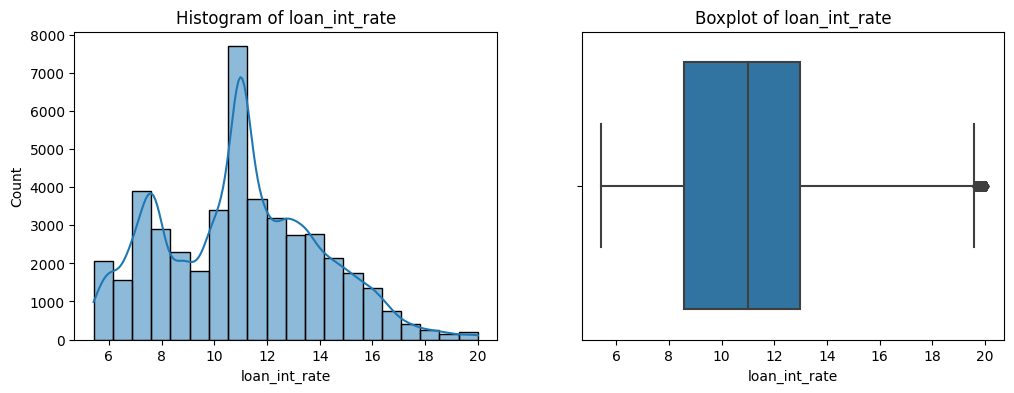

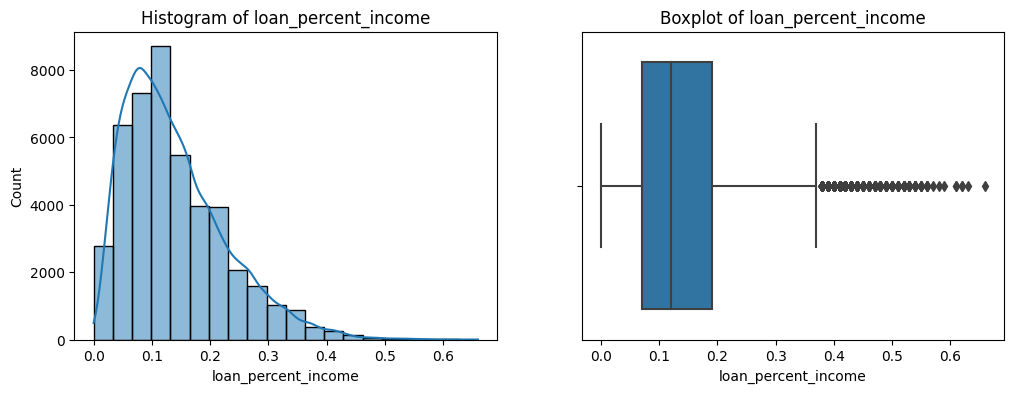

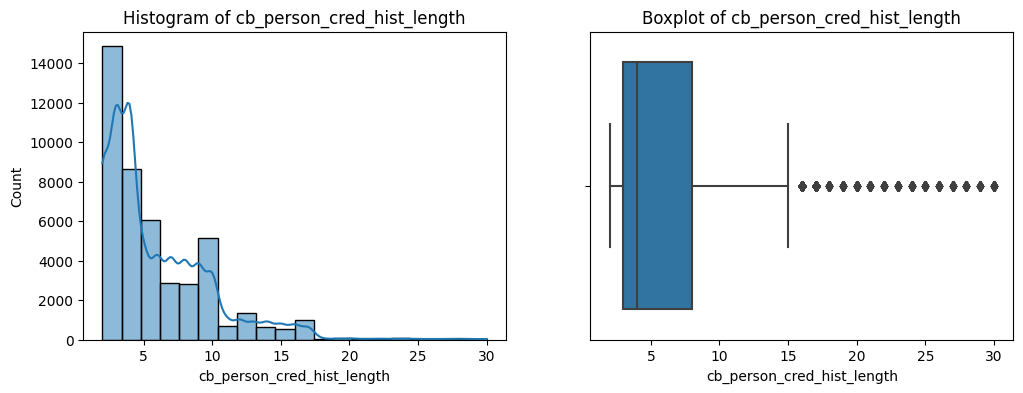

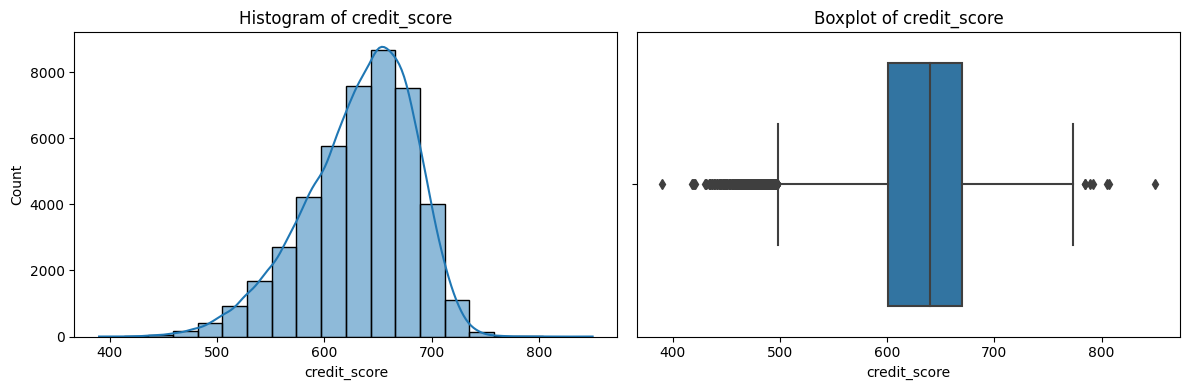

In [8]:
for i in numeric_cols:
    if i == "loan_status":
        continue
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(eda[i], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {i}")

    # Boxplot
    sns.boxplot(x=eda[i], ax=axes[1])
    axes[1].set_title(f"Boxplot of {i}")

plt.tight_layout()
plt.show()

### Section 4.2 Conclusion

**Categorical variables:**
- Majority of applicants are male, rent their homes, hold a Bachelor's degree, and intend to use the loan for education
- Previous loan defaults are split roughly 50/50 — unusually high for real bank data, suggesting the dataset oversamples defaulted borrowers for classification purposes.

**Numeric variables:**
- person_age and person_emp_exp contain implausible outliers (140+ years, 120+ years experience) — likely data entry errors. Age is excluded from modeling on regulatory grounds so this does not affect results.
- person_income is extremely right skewed — consistent with Phase 1 findings, winsorization and log transformation required
- credit_score is approximately normally distributed — no transformation needed
- loan_amnt shows a multimodal distribution suggesting distinct loan size clusters
- loan_int_rate and loan_percent_income are mildly skewed — winsorization sufficient

## 4.3 Bivariete Analysis

### 4.3.1 Categorical Data vs Loan Status

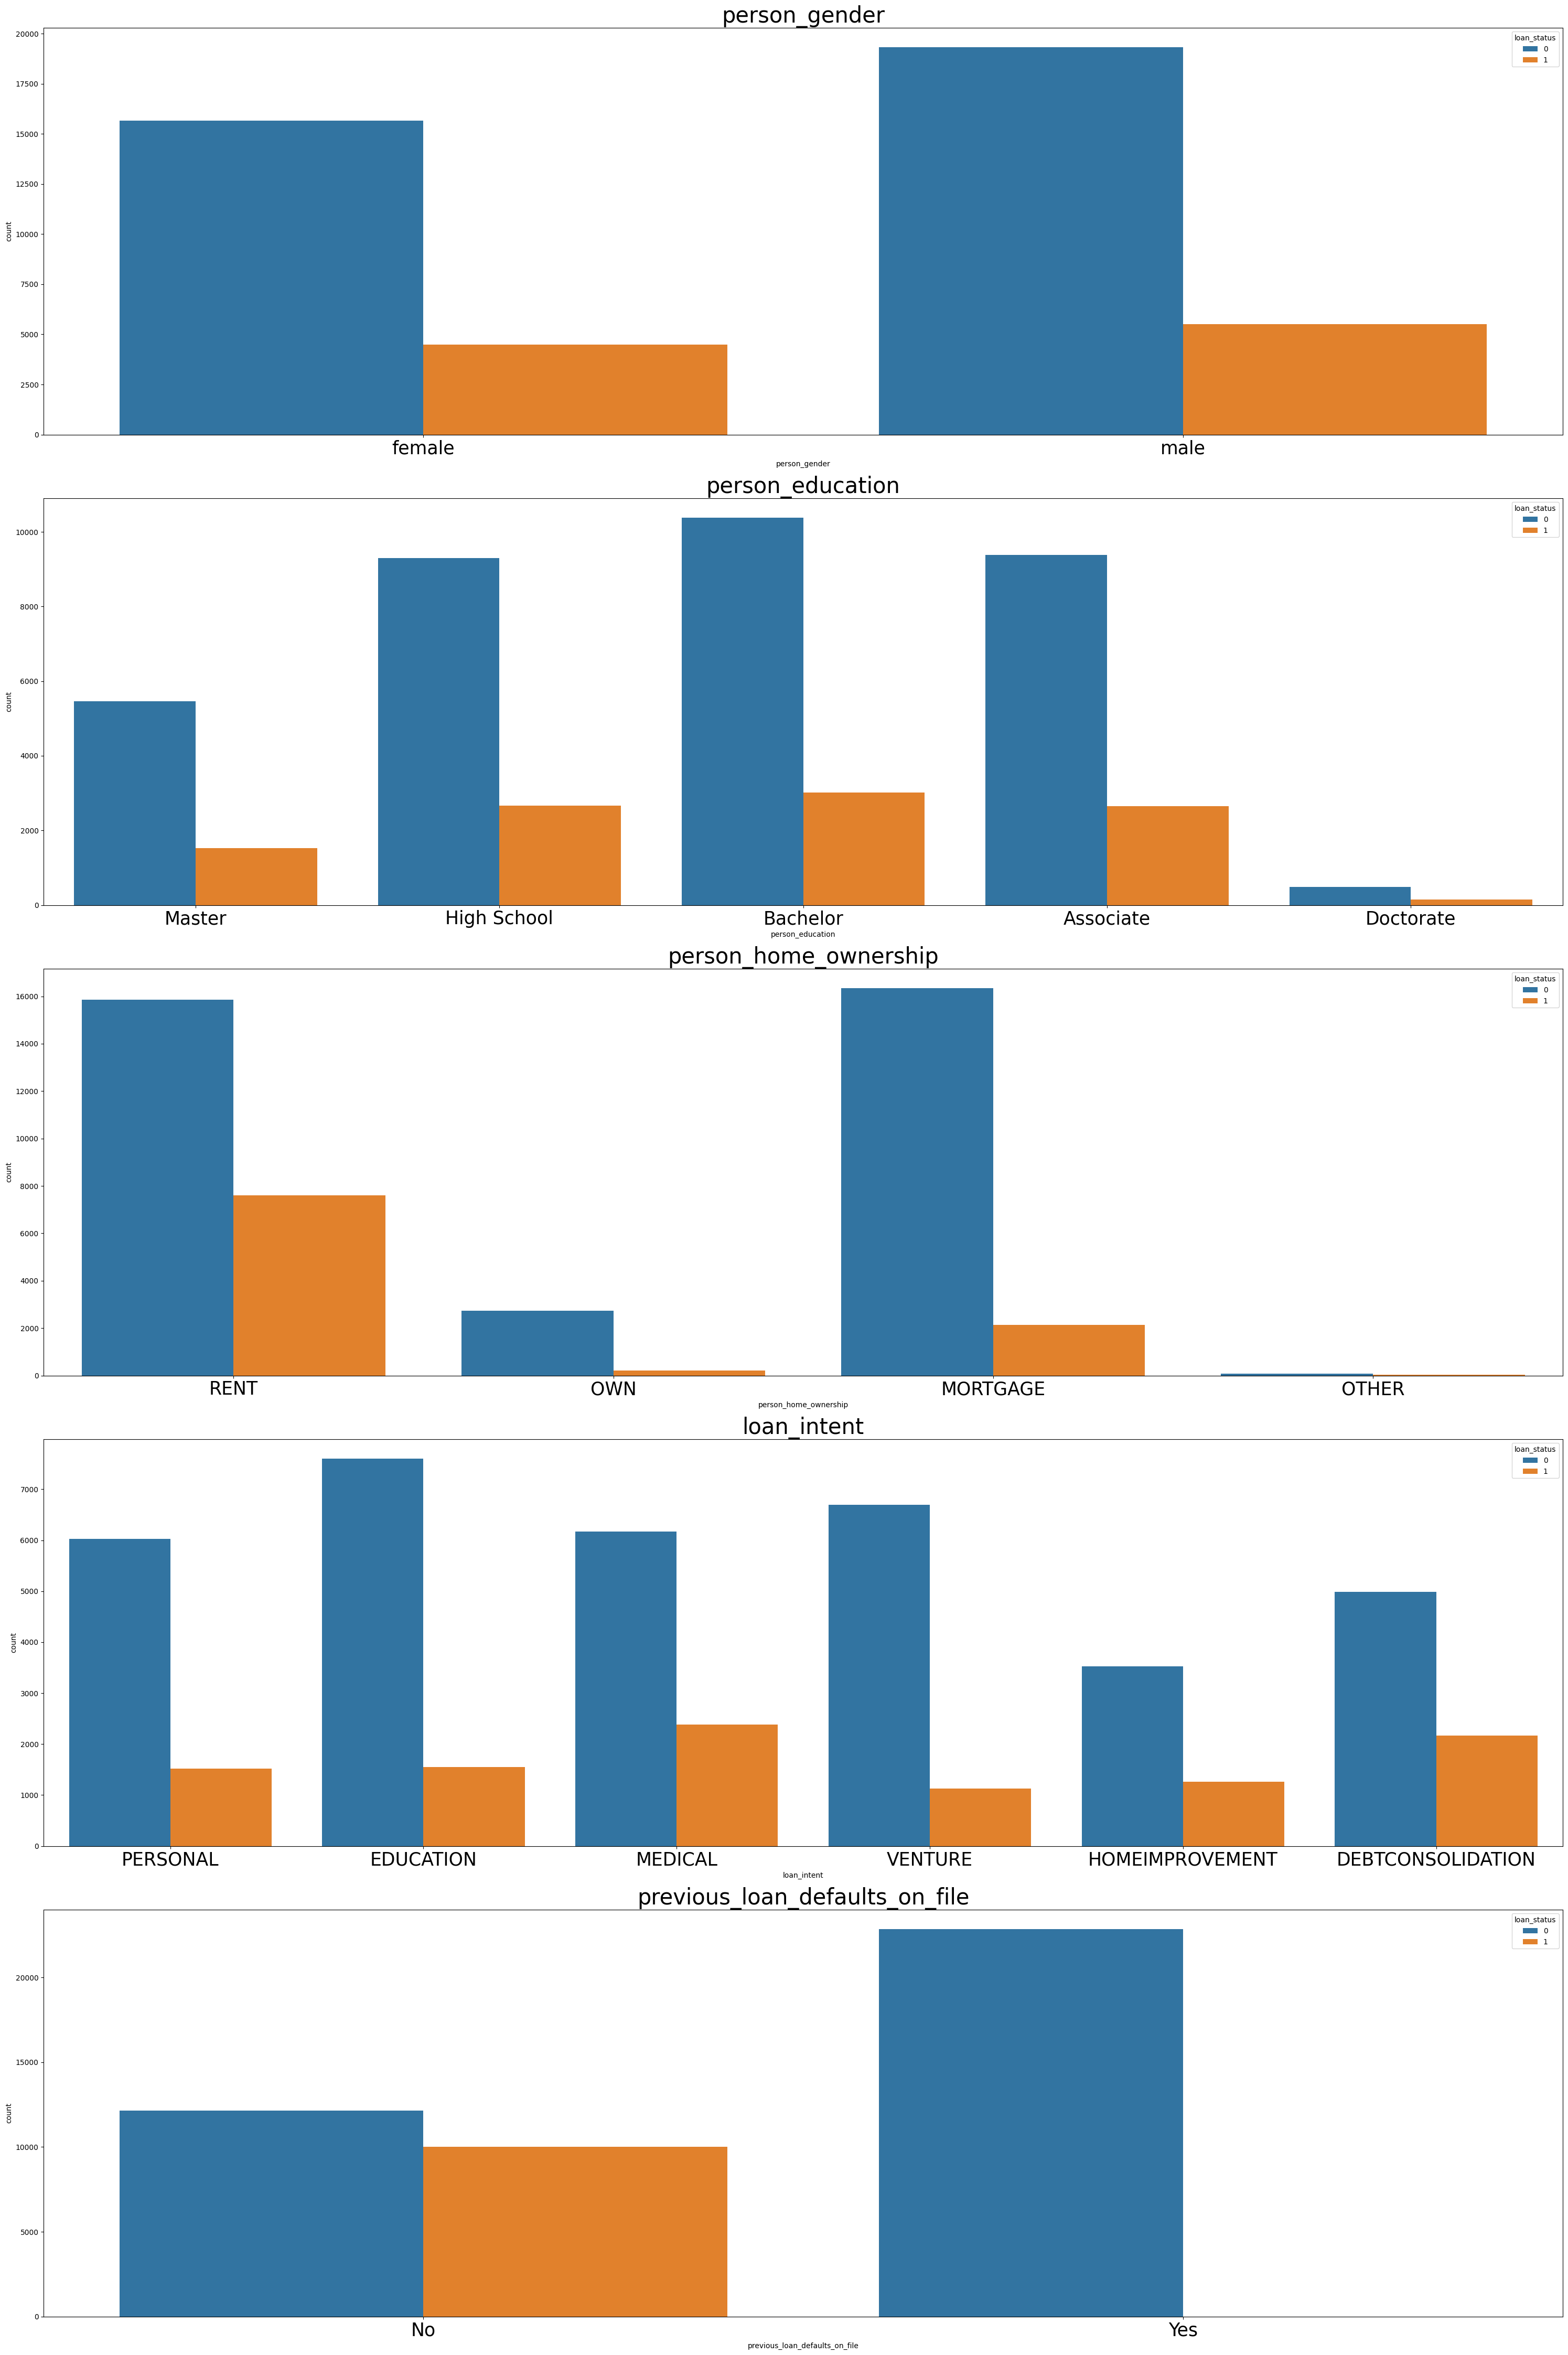

In [9]:
plt.figure(figsize=(30, 45))
plot_idx = 1

for col in categorical_cols:
    if col == "loan_status":
        continue
    plt.subplot(5, 1, plot_idx)
    sns.countplot(data=eda, x=col, hue = "loan_status")
    plt.title(col, fontsize=30)
    plt.xticks(fontsize=25)  
    plot_idx += 1

plt.tight_layout()
plt.show()



### 4.3.2 Numeric Data vs Loan Status

<Figure size 1000x1000 with 0 Axes>

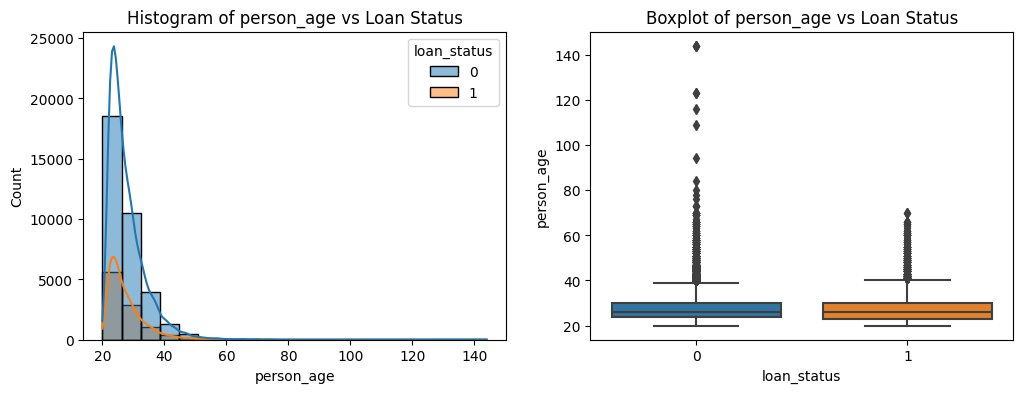

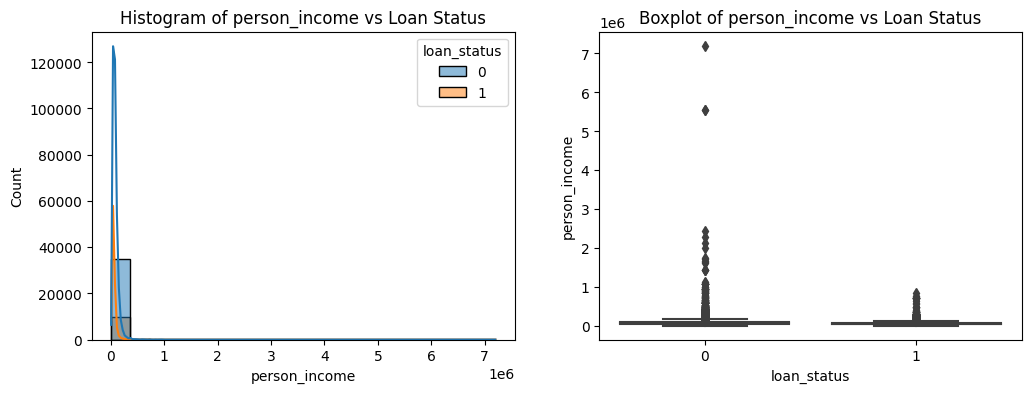

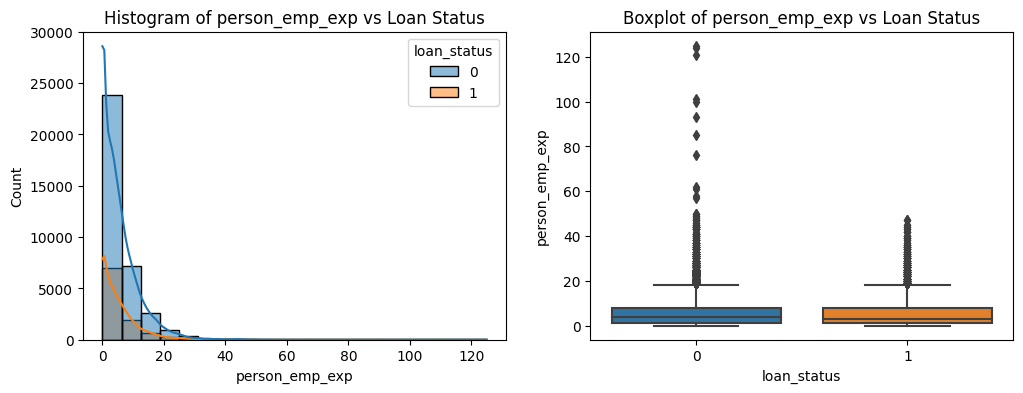

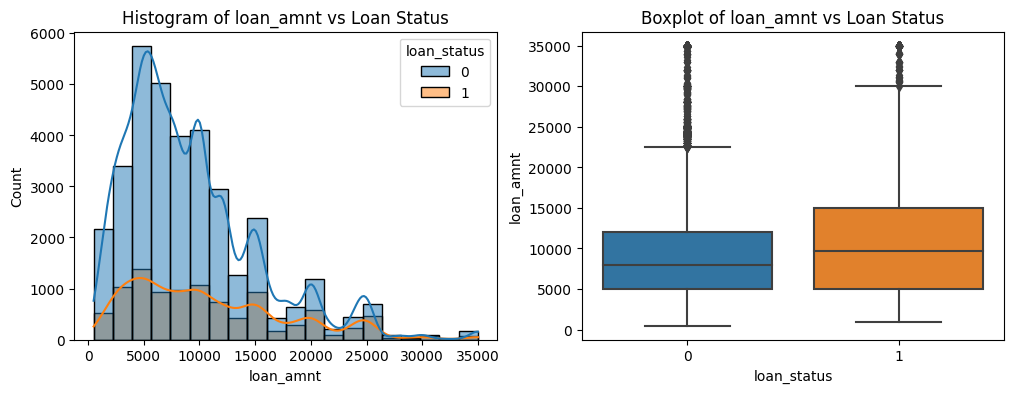

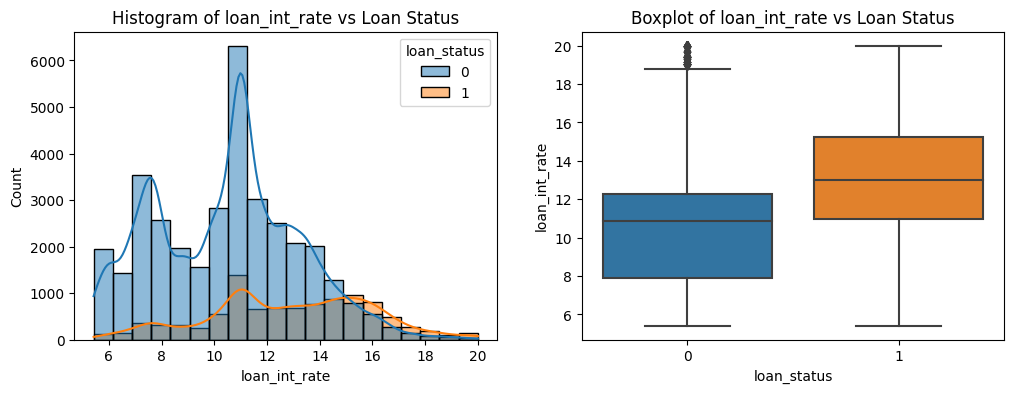

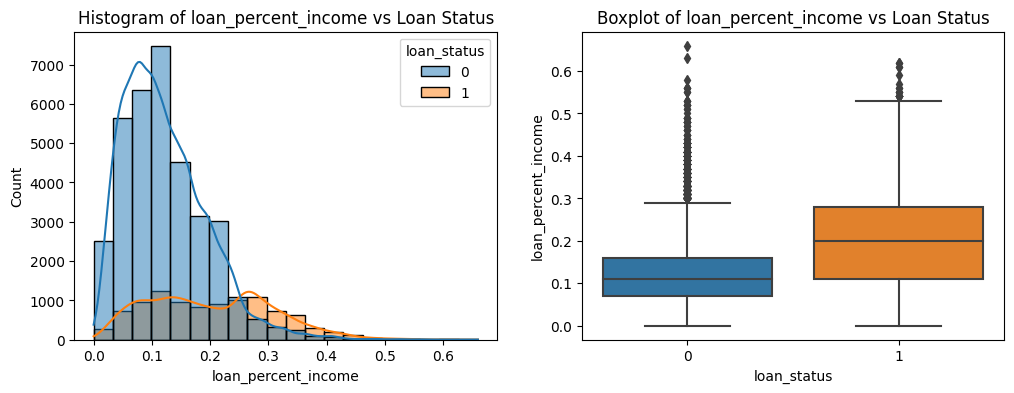

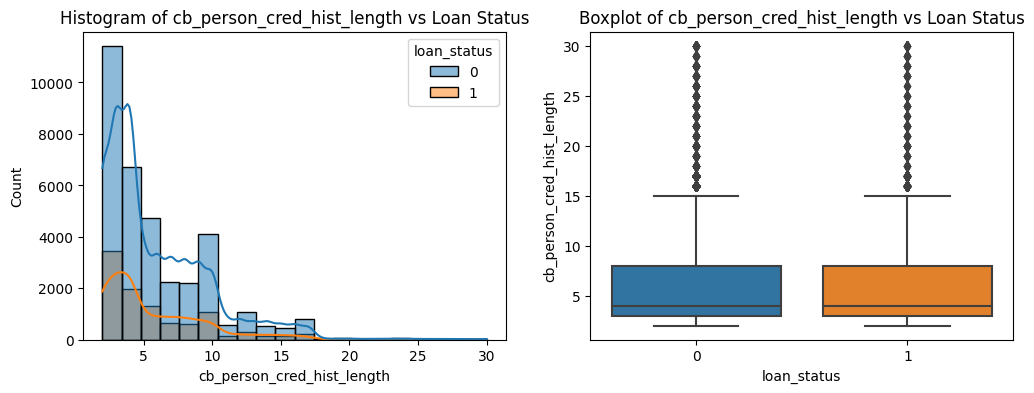

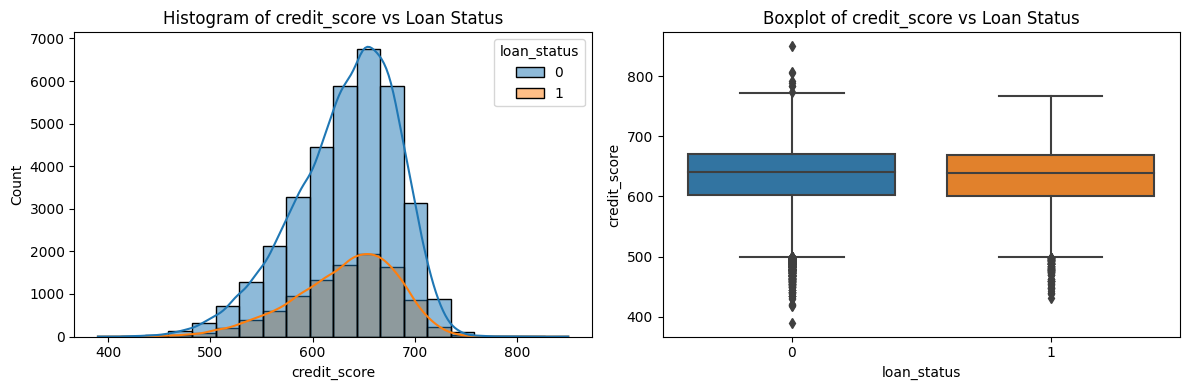

In [10]:
for i in numeric_cols:
    if i == "loan_status":
        continue
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(data=eda, x=i, hue="loan_status", bins=20, kde=True, ax=axes[0])   
    axes[0].set_title(f"Histogram of {i} vs Loan Status")

    # Boxplot
    sns.boxplot(data=eda, y=i, x="loan_status", ax=axes[1])
    axes[1].set_title(f"Boxplot of {i} vs Loan Status")

plt.tight_layout()
plt.show()

### Section 4.3 Conclusion

**Categorical variables:**
- previous_loan_defaults_on_file is the strongest predictor, applicants with a previous default are almost universally rejected
- Renters are more likely to be approved than mortgage holders. This is counterintuitive, investigated further in feature selection
- Education level shows no meaningful difference between approved and rejected groups

**Numeric variables:**
- credit_score, person_income, person_emp_exp, and credit history length show heavily overlapping distributions meaning limited individual predictive power

- loan_int_rate, loan_amnt, and loan_percent_income are all higher for approved loans. These are counterintuitive findings that warrant attention. For loan_int_rate specifically, the positive association with approval suggests the rate may partially reflect the bank's own risk pricing rather than being an independent predictor of creditworthiness. This potential circularity is flagged here and discussed further in the notebook conclusion.

- person_age distributions are similar across groups, shown for completeness, excluded from modeling on regulatory grounds

# 5. Train Test Split

The train/test split is performed after EDA as no transformations were applied during exploration. All EDA used the full dataset for visualisation purposes only.

In [11]:
# Target variable is Loan_Status, so model predicts if a loan is approved/rejected
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6. Data Transformation

Features person_age and person_gender are excluded from the model. Under GDPR Article 22 and EBA guidelines on non-discriminatory credit models, protected characteristics should not serve as direct inputs to automated credit decisions. Employment experience (person_emp_exp) and credit history length (cb_person_cred_hist_length) capture the economically relevant information from age without using the protected characteristic directly.

In Phase 1 feature engineering created four derived variables: Total_Income, DTI, Debt_Ratio, and Has_Coapplicant. Of these, only Has_Coapplicant showed meaningful influence in the logistic regression model while the others were largely redundant with their component variables due to multicollinearity. Has_Coapplicant was informative specifically because it converted a highly skewed continuous variable (Coapplicant_Income, which was zero for most applicants) into a clean binary indicator that logistic regression could use effectively.

In Phase 2 this engineering is unnecessary for two reasons:

1. loan_percent_income is already equivalent to the DTI ratio constructed in Phase 1. It is pre-calculated in the dataset.

2. There is no Coapplicant_Income variable in Phase 2, so the Has_Coapplicant logic does not apply. The dataset's richer feature set eliminates the need for manual feature construction.

## 6.1 Initial Feature Selection

In [12]:
X_train = X_train.drop(["person_age", "person_gender"],axis=1)
numeric_col = X_train.select_dtypes(include="number").columns.tolist()

## 6.2 Skewness Assessment

Test is transformed after assessing its affects on train data.

In [13]:
#Calculating skewness of data determine
skew_train = X_train[numeric_col].skew() 
skew_test = X_test[numeric_col].skew() 
print("Skewness of train data (numeric):\n", skew_train, "\n")

Skewness of train data (numeric):
 person_income                 36.159082
person_emp_exp                 2.594476
loan_amnt                      1.176414
loan_int_rate                  0.207298
loan_percent_income            1.043264
cb_person_cred_hist_length     1.625431
credit_score                  -0.615153
dtype: float64 



Skewness was calculated to quantitatively verify the qualitative observations from EDA and guide transformation decisions:

- person_income and person_emp_exp show extreme positive skew. Extreme values represent valid high-income and long-tenure applicants rather than data errors and are retained with capped influence. **Winsorization followed by log transformation is applied** to reduce skewness while preserving the underlying signal.
- loan_amnt, loan_percent_income, and cb_person_cred_hist_length show mild positive skew. **Winsorization is only applied**, log transformation not warranted.
- credit_score and loan_int_rate are approximately normally distributed. **These will be left untransformed.** Extreme values are minimal and do not materially affect the distribution shape.

## 6.3 Winsorazation and log Transformation

In [14]:
#Selecting features that need winsorazationa and which will also be log transformed
skew_win = skew_train[skew_train >= 1].index.tolist()
skew_transform = skew_train[skew_train >= 2].index.tolist()

In [15]:
# Calculate limits from training data only
limits = {}
for i in skew_win:
    limits[i] = {
        "lower": X_train[i].quantile(0.01),
        "upper": X_train[i].quantile(0.99)
    }

# Apply transformations as new columns, keep originals untouched
def transform_data(data, limits, skew_transform):
    data = data.copy()
    for i in limits:
        capped = np.clip(data[i], limits[i]["lower"], limits[i]["upper"])
        if i in skew_transform:
            data[f"{i}_log"] = np.log1p(capped)
        else:
            data[f"{i}_win"] = capped
    return data

X_train = transform_data(X_train, limits, skew_transform)

# Skewness after — only transformed columns
transformed_cols = [c for c in X_train.columns if "_log" in c or "_win" in c]
print(X_train[transformed_cols].skew().round(3))

Skewness after transformation:
person_income_log                 0.061
person_emp_exp_log               -0.148
loan_amnt_win                     1.019
loan_percent_income_win           0.907
cb_person_cred_hist_length_win    1.215
dtype: float64


## 6.4 Comparison of Before and After Transformation


In [16]:
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
#print("Skewness after transformation:")
skews = X_train[numeric_cols].skew().round(3)

In [17]:
for i in numeric_col:
    print(f"Variable: {i}")
    print(f"  Original skew: {skews.get(i, 'N/A')}")
    print(f"  Capped skew: {skews.get(f'{i}_win', 'N/A')}")
    print(f"  Log-transformed skew: {skews.get(f'{i}_log', 'N/A')}")
    print("-" * 40)

Variable: person_income
  Original skew: 36.159
  Capped skew: N/A
  Log-transformed skew: 0.061
----------------------------------------
Variable: person_emp_exp
  Original skew: 2.594
  Capped skew: N/A
  Log-transformed skew: -0.148
----------------------------------------
Variable: loan_amnt
  Original skew: 1.176
  Capped skew: 1.019
  Log-transformed skew: N/A
----------------------------------------
Variable: loan_int_rate
  Original skew: 0.207
  Capped skew: N/A
  Log-transformed skew: N/A
----------------------------------------
Variable: loan_percent_income
  Original skew: 1.043
  Capped skew: 0.907
  Log-transformed skew: N/A
----------------------------------------
Variable: cb_person_cred_hist_length
  Original skew: 1.625
  Capped skew: 1.215
  Log-transformed skew: N/A
----------------------------------------
Variable: credit_score
  Original skew: -0.615
  Capped skew: N/A
  Log-transformed skew: N/A
----------------------------------------


## 6.5 One-hot-encoding and Label encoding Categorical variables

In [18]:
cat_col = X_train.drop("previous_loan_defaults_on_file",axis=1).select_dtypes(include=["object"]).columns.tolist()
X_train = pd.get_dummies(X_train, columns=["previous_loan_defaults_on_file"], drop_first=True)

X_train = pd.get_dummies(X_train, columns=cat_col)

One reference category is dropped from each multi-category variable to avoid perfect multicollinearity in the logistic regression model. The most frequent category is selected as the reference in each case — Bachelor for education, RENT for home ownership, and EDUCATION for loan intent. Coefficients for remaining categories are interpreted relative to these reference groups.

In [19]:
drop_reference = [
    "person_education_Bachelor",
    "person_home_ownership_RENT",
    "loan_intent_EDUCATION"
]

X_train = X_train.drop(drop_reference, axis=1)


In [20]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36000 entries, 6048 to 44095
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_income                       36000 non-null  float64
 1   person_emp_exp                      36000 non-null  int64  
 2   loan_amnt                           36000 non-null  float64
 3   loan_int_rate                       36000 non-null  float64
 4   loan_percent_income                 36000 non-null  float64
 5   cb_person_cred_hist_length          36000 non-null  float64
 6   credit_score                        36000 non-null  int64  
 7   person_income_log                   36000 non-null  float64
 8   person_emp_exp_log                  36000 non-null  float64
 9   loan_amnt_win                       36000 non-null  float64
 10  loan_percent_income_win             36000 non-null  float64
 11  cb_person_cred_hist_length_win      36

## 6.6 Test Data Transformation

In [21]:
#Doing the transformation for test data
X_test =  X_test.drop(["person_age", "person_gender"],axis=1)

X_test = transform_data(X_test, limits, skew_transform)

X_test = pd.get_dummies(X_test, columns=["previous_loan_defaults_on_file"], drop_first=True)

X_test = pd.get_dummies(X_test, columns=cat_col)

X_test = X_test.drop(drop_reference, axis=1)

X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9000 entries, 10750 to 34694
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_income                       9000 non-null   float64
 1   person_emp_exp                      9000 non-null   int64  
 2   loan_amnt                           9000 non-null   float64
 3   loan_int_rate                       9000 non-null   float64
 4   loan_percent_income                 9000 non-null   float64
 5   cb_person_cred_hist_length          9000 non-null   float64
 6   credit_score                        9000 non-null   int64  
 7   person_income_log                   9000 non-null   float64
 8   person_emp_exp_log                  9000 non-null   float64
 9   loan_amnt_win                       9000 non-null   float64
 10  loan_percent_income_win             9000 non-null   float64
 11  cb_person_cred_hist_length_win      90

### Section 6 Conclusion

Data transformation was applied to the training dataset and the same parameters were used to transform the test dataset, ensuring no data leakage.

**Feature decisions:**
- person_age and person_gender excluded on regulatory grounds — GDPR Article 22 and EBA guidelines on non-discriminatory credit models

**Skewness and transformation:**
- person_income and person_emp_exp (skew > 2): winsorization and log transformation applied — extreme values are valid observations retained 
  with capped influence
- loan_amnt, loan_percent_income, cb_person_cred_hist_length (skew > 1): winsorization only — mild skew does not warrant log transformation
- credit_score and loan_int_rate (skew < 1): left untransformed — approximately normal distributions confirmed by histogram analysis in EDA

**Encoding:**
- previous_loan_defaults_on_file encoded as binary (drop_first=True)
- person_education, person_home_ownership, and loan_intent one-hot encoded with reference category dropped to prevent perfect multicollinearity — Bachelor, RENT, and EDUCATION respectively selected as reference categories based on highest frequency

All transformation decisions were evaluated on training data only and applied consistently to both train and test sets. Transformed datasets saved for Notebook 2.

# 7. Uploading Data

In [22]:
X_train.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\train_data\X_train.csv", index=False)
y_train.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\train_data\y_train.csv", index=False)

X_test.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\test_data\X_test.csv", index=False)
y_test.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\test_data\y_test.csv", index=False)


# 8. Conclusion

In this notebook, exploratory data analysis and data preparation were performed on the Phase 2 loan dataset to prepare it for modeling. The key findings and steps are summarised below:

**Data Overview**
- The dataset contains 45,000 observations across 14 features with no missing values or duplicate rows. This dataset is substantially cleaner than Phase 1 and requires minimal preprocessing.
- person_age and person_gender were excluded on regulatory grounds following GDPR Article 22 and EBA guidelines on non-discriminatory credit models after EDA. Employment experience and credit history length capture the economically relevant information without the protected characteristics.

**Exploratory Data Analysis**
- previous_loan_defaults_on_file is the strongest predictor. Applicants with a prior default are almost universally rejected, consistent with Phase 1 where Credit_History was the dominant variable.
- Education level, credit score, income, employment length, and credit history length show limited individual association with loan status.
- loan_int_rate, loan_amnt, and loan_percent_income are all higher for approved loans. These are counterintuitive findings. For loan_int_rate this is consistent with potential circularity. Interest rate may partially reflect the bank's own risk pricing rather than being an independent predictor.
- Renters and applicants intending medical loans show higher approval rates.
- Previous default on file leads to near-certain rejection regardless of other characteristics.

**Feature Engineering**
- No feature engineering was required. loan_percent_income is equivalent to the DTI ratio manually constructed in Phase 1 and is already present in the dataset. The absence of a coapplicant income variable means the Has_Coapplicant indicator from Phase 1 does not apply here.

**Skewness and Transformation**
- Skewness was calculated to quantitatively verify EDA observations and guide transformation decisions. Winsorization limits were calculated from training data only and applied to both train and test sets to prevent data leakage. Data was transformed foloowing this:
  - person_income and person_emp_exp (skew > 2): winsorization and log transformation applied
  - loan_amnt, loan_percent_income, cb_person_cred_hist_length (skew > 1): winsorization only
  - credit_score and loan_int_rate (skew < 1): left untransformed — approximately normal distributions confirmed by histogram analysis

**Encoding**
- previous_loan_defaults_on_file encoded as binary using one-hot encoding with drop_first=True.
- person_education, person_home_ownership, and loan_intent label encoded using one-hot encoding. The most frequent reference category dropped from each to prevent perfect multicollinearity in logistic regression:
  - Bachelor for education
  - RENT for home ownership 
  - EDUCATION for loan intent

**Next Steps**
- Transformed train and test datasets saved for Notebook 2.
- Feature selection, model development, and risk segmentation will be conducted in Notebook 2 using the prepared datasets.